# Phase 3 — Biologie des systèmes : voie HER2 → PI3K → AKT

Objectif : modéliser mathématiquement (équations différentielles ordinaires, ODE) une voie de signalisation liée au sous-type "HER2-enrichi" d'OncoPrint, pour simuler l'effet d'un blocage thérapeutique — et surtout, un mécanisme de **résistance** documenté quand ce blocage ne suffit pas.

**Avertissement honnête** : les constantes cinétiques utilisées ici sont illustratives, choisies pour obtenir un comportement qualitativement correct (cascade qui s'active, puis se bloque avec le médicament) — ce n'est **pas** un modèle quantitatif validé sur des données expérimentales réelles. L'objectif est de démontrer la méthode (modélisation ODE d'une voie de signalisation avec Tellurium), pas de produire un résultat biologique publiable.

## Le modèle

Cascade de kinases à 3 étages, chaque protéine existant sous forme inactive/active (ex. `HER2i` / `HER2a`) :

`HER2i ⇌ HER2a → active PI3Ki ⇌ PI3Ka → active AKTi ⇌ AKTa`

Un "médicament" peut accélérer la désactivation d'un nœud choisi (HER2, PI3K ou AKT) — c'est la simplification retenue pour représenter un inhibiteur de kinase (type lapatinib pour HER2).

In [1]:
import matplotlib.pyplot as plt
import tellurium as te

MODEL = '''
model her2_pi3k_akt
  J1: HER2i -> HER2a; k_on*HER2i
  J2: HER2a -> HER2i; k_off*HER2a + drug_her2*k_inhib*HER2a
  J3: PI3Ki -> PI3Ka; k1*HER2a*PI3Ki + basal_pi3k*PI3Ki
  J4: PI3Ka -> PI3Ki; k1r*PI3Ka + drug_pi3k*k_inhib*PI3Ka
  J5: AKTi -> AKTa; k2*PI3Ka*AKTi
  J6: AKTa -> AKTi; k2r*AKTa + drug_akt*k_inhib*AKTa

  HER2i = 1; HER2a = 0
  PI3Ki = 1; PI3Ka = 0
  AKTi = 1; AKTa = 0

  k_on = 0.5; k_off = 0.15
  k1 = 1.0; k1r = 0.8
  k2 = 1.0; k2r = 0.8
  k_inhib = 10
  basal_pi3k = 0
  drug_her2 = 0; drug_pi3k = 0; drug_akt = 0
end
'''

def simulate(t_end=60, n_points=150, **overrides):
    r = te.loada(MODEL)
    for param, value in overrides.items():
        setattr(r, param, value)
    return r.simulate(0, t_end, n_points)

## 1. Cascade sans traitement

Le signal se propage de HER2 vers AKT — c'est l'état "tumeur active" de référence.

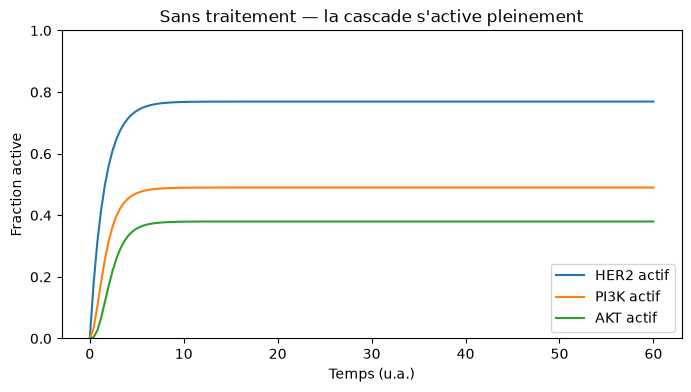

AKT actif à l'état stationnaire : 0.38


In [2]:
baseline = simulate()

plt.figure(figsize=(8, 4))
plt.plot(baseline['time'], baseline['[HER2a]'], label='HER2 actif')
plt.plot(baseline['time'], baseline['[PI3Ka]'], label='PI3K actif')
plt.plot(baseline['time'], baseline['[AKTa]'], label='AKT actif')
plt.xlabel('Temps (u.a.)'); plt.ylabel('Fraction active')
plt.title("Sans traitement — la cascade s'active pleinement")
plt.legend(); plt.ylim(0, 1)
plt.show()

print('AKT actif à l\'état stationnaire :', round(baseline['[AKTa]'][-1], 3))

## 2. Blocage de HER2 (ex. lapatinib)

On simule un inhibiteur qui accélère la désactivation de HER2 (`drug_her2 = 1`). Le signal s'éteint en cascade sur les trois étages.

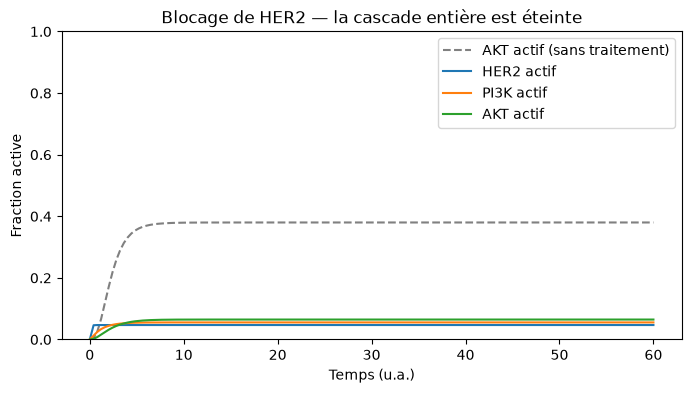

AKT actif à l'état stationnaire (HER2 bloqué) : 0.065


In [3]:
blocked = simulate(drug_her2=1)

plt.figure(figsize=(8, 4))
plt.plot(baseline['time'], baseline['[AKTa]'], '--', color='gray', label='AKT actif (sans traitement)')
plt.plot(blocked['time'], blocked['[HER2a]'], label='HER2 actif')
plt.plot(blocked['time'], blocked['[PI3Ka]'], label='PI3K actif')
plt.plot(blocked['time'], blocked['[AKTa]'], label='AKT actif')
plt.xlabel('Temps (u.a.)'); plt.ylabel('Fraction active')
plt.title('Blocage de HER2 — la cascade entière est éteinte')
plt.legend(); plt.ylim(0, 1)
plt.show()

print('AKT actif à l\'état stationnaire (HER2 bloqué) :', round(blocked['[AKTa]'][-1], 3))

## 3. Résistance : mutation activatrice de PI3K en aval

**Fait clinique documenté** : les mutations activatrices de *PIK3CA* (le gène codant la sous-unité catalytique de PI3K) sont l'un des mécanismes de résistance connus au trastuzumab dans les cancers du sein HER2+ — elles maintiennent la voie active *en aval* du blocage de HER2.

On simule ça avec `basal_pi3k > 0` : PI3K s'active indépendamment de HER2, même quand HER2 reste bloqué.

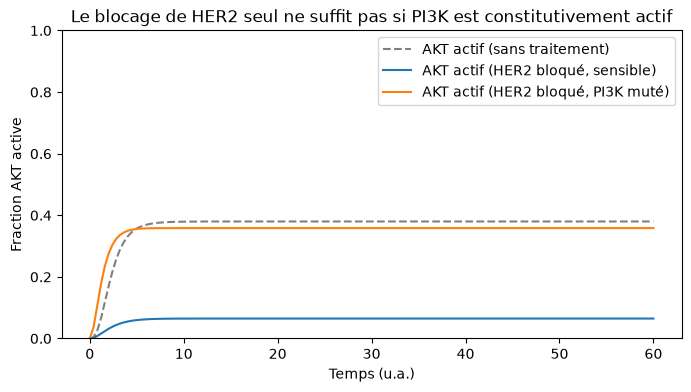

AKT actif — HER2 bloqué, sensible   : 0.065
AKT actif — HER2 bloqué, résistant  : 0.359
AKT actif — sans traitement         : 0.38


In [4]:
resistant = simulate(drug_her2=1, basal_pi3k=0.6)

plt.figure(figsize=(8, 4))
plt.plot(baseline['time'], baseline['[AKTa]'], '--', color='gray', label='AKT actif (sans traitement)')
plt.plot(blocked['time'], blocked['[AKTa]'], label='AKT actif (HER2 bloqué, sensible)')
plt.plot(resistant['time'], resistant['[AKTa]'], label='AKT actif (HER2 bloqué, PI3K muté)')
plt.xlabel('Temps (u.a.)'); plt.ylabel('Fraction AKT active')
plt.title('Le blocage de HER2 seul ne suffit pas si PI3K est constitutivement actif')
plt.legend(); plt.ylim(0, 1)
plt.show()

print('AKT actif — HER2 bloqué, sensible   :', round(blocked['[AKTa]'][-1], 3))
print('AKT actif — HER2 bloqué, résistant  :', round(resistant['[AKTa]'][-1], 3))
print('AKT actif — sans traitement         :', round(baseline['[AKTa]'][-1], 3))

**Lecture** : malgré un blocage quasi total de HER2 (identique au scénario 2), la fraction d'AKT actif remonte presque au niveau "sans traitement" dès que PI3K a une activité basale indépendante. C'est exactement la logique clinique derrière la prescription d'un inhibiteur de PI3K (ex. alpelisib) en complément d'une thérapie anti-HER2 chez les patientes porteuses d'une mutation *PIK3CA*.

## 4. Simulateur — choisir le point de blocage

Fonction interactive : on choisit quel nœud bloquer (HER2, PI3K ou AKT) et on compare au signal non traité.

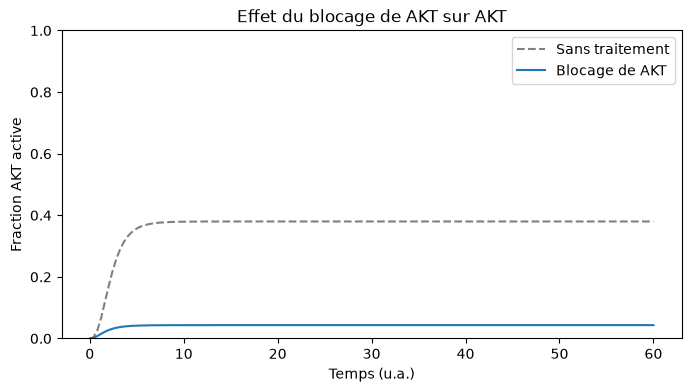

{'AKTa_sans_traitement': np.float64(0.38), 'AKTa_traite': np.float64(0.043)}

In [5]:
def compare_blockade(node, basal_pi3k=0, t_end=60):
    """node: 'her2', 'pi3k' ou 'akt'"""
    drug_kwargs = {f"drug_{node}": 1}
    treated = simulate(t_end=t_end, basal_pi3k=basal_pi3k, **drug_kwargs)
    untreated = simulate(t_end=t_end, basal_pi3k=basal_pi3k)

    plt.figure(figsize=(8, 4))
    plt.plot(untreated['time'], untreated['[AKTa]'], '--', color='gray', label='Sans traitement')
    plt.plot(treated['time'], treated['[AKTa]'], label=f'Blocage de {node.upper()}')
    plt.xlabel('Temps (u.a.)'); plt.ylabel('Fraction AKT active')
    plt.title(f'Effet du blocage de {node.upper()} sur AKT')
    plt.legend(); plt.ylim(0, 1)
    plt.show()

    return {"AKTa_sans_traitement": round(untreated['[AKTa]'][-1], 3), "AKTa_traite": round(treated['[AKTa]'][-1], 3)}

compare_blockade('akt')

Bloquer AKT directement (dernier étage) éteint le signal final quel que soit l'état de HER2/PI3K en amont — contrairement au blocage de HER2 qui échoue en cas de mutation *PIK3CA*. Ça illustre pourquoi cibler un nœud plus en aval peut contourner certaines résistances, au prix probable de plus d'effets secondaires (AKT est impliqué dans de nombreuses voies physiologiques, pas seulement la prolifération tumorale).

## 5. Courbe dose-réponse

On fait varier l'intensité du blocage de HER2 (`drug_her2` de 0 à 1) et on regarde le niveau d'AKT actif à l'état stationnaire — le pendant "biologie des systèmes" de la courbe dose-réponse QSAR de la Phase 2.

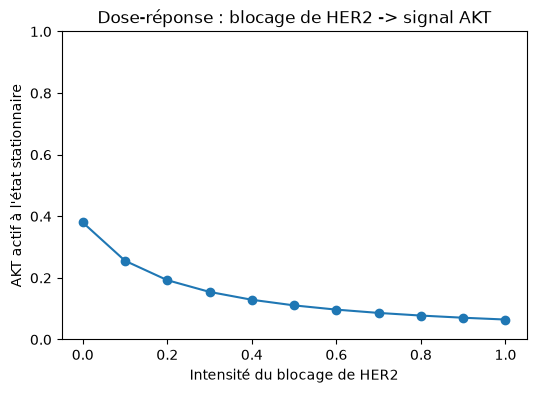

In [6]:
import numpy as np

doses = np.linspace(0, 1, 11)
akt_steady = [simulate(drug_her2=d)['[AKTa]'][-1] for d in doses]

plt.figure(figsize=(6, 4))
plt.plot(doses, akt_steady, marker='o')
plt.xlabel("Intensité du blocage de HER2")
plt.ylabel("AKT actif à l'état stationnaire")
plt.title("Dose-réponse : blocage de HER2 -> signal AKT")
plt.ylim(0, 1)
plt.show()